In [13]:
# Célula 20: imports
from scipy.stats import chi2_contingency, spearmanr, kruskal
from sklearn.metrics import mutual_info_score, normalized_mutual_info_score
from sklearn.feature_selection import mutual_info_classif
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["length", "diameter", "height", "whole_weight",
            "shucked_weight", "viscera_weight", "shell_weight"]

(3132, 9)
type
1    1078
2    1003
3    1051
Name: count, dtype: int64
Contagens:
type    1    2    3
sex                
F     138  344  471
I     717  214  111
M     223  445  469 

Proporção de cada type dentro de cada sex (linhas somam 1):
type      1      2      3
sex                      
F     0.145  0.361  0.494
I     0.688  0.205  0.107
M     0.196  0.391  0.412 

Proporção de cada sex dentro de cada type (colunas somam 1):
type      1      2      3
sex                      
F     0.128  0.343  0.448
I     0.665  0.213  0.106
M     0.207  0.444  0.446 

Qui-quadrado = 860.8 (gl=4), p = 5.12e-185
Cramér's V   = 0.371
Informação mútua (nats)       = 0.1402
Informação mútua normalizada  = 0.1278


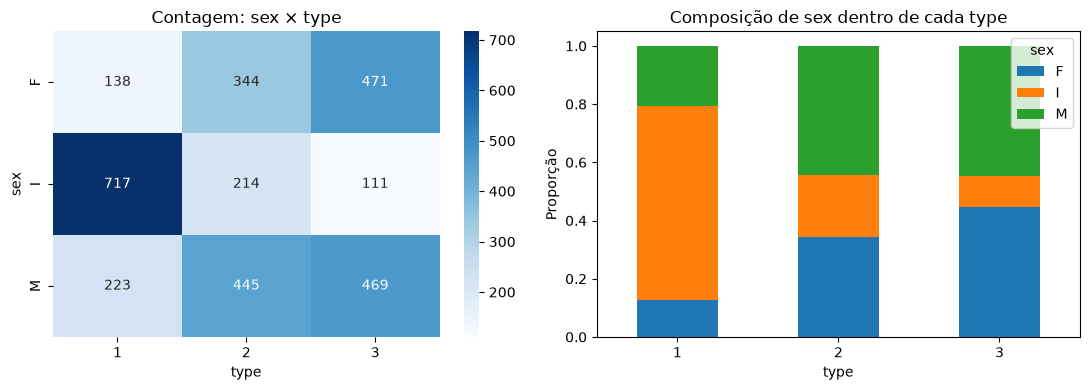

In [14]:
# Célula 21: sex × type (tabela de contingência, qui-quadrado, Cramér's V, informação mútua)
# Célula 3: carregar dados
# Célula 2: configurações
RANDOM_STATE = 42

N_ESTIMATORS = 300        # nº de árvores
MAX_DEPTH = 8             # da curva de validação: 5 a 8 rendem o mesmo que profundidades maiores
MIN_SAMPLES_LEAF = 1
K = 10                    # nº de folds

REMOVER_SOMA_INVALIDA = False   # True: remove linhas com shucked+viscera+shell > whole
TOL = 1e-9                      # tolerância para erro de ponto flutuante

df = pd.read_csv("abalone_dataset.csv")
print(df.shape)
print(df["type"].value_counts().sort_index())

X = df.drop(columns="type")
y = df["type"]
cat_cols = ["sex"]

tab = pd.crosstab(df["sex"], df["type"])
print("Contagens:")
print(tab, "\n")
print("Proporção de cada type dentro de cada sex (linhas somam 1):")
print(pd.crosstab(df["sex"], df["type"], normalize="index").round(3), "\n")
print("Proporção de cada sex dentro de cada type (colunas somam 1):")
print(pd.crosstab(df["sex"], df["type"], normalize="columns").round(3), "\n")

chi2, p, dof, _ = chi2_contingency(tab)
n = tab.values.sum()
cramer_v = np.sqrt(chi2 / (n * (min(tab.shape) - 1)))
print(f"Qui-quadrado = {chi2:.1f} (gl={dof}), p = {p:.3g}")
print(f"Cramér's V   = {cramer_v:.3f}")
print(f"Informação mútua (nats)       = {mutual_info_score(df['sex'], df['type']):.4f}")
print(f"Informação mútua normalizada  = {normalized_mutual_info_score(df['sex'], df['type']):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(tab, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Contagem: sex × type")
pd.crosstab(df["type"], df["sex"], normalize="index").plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Composição de sex dentro de cada type")
axes[1].set_ylabel("Proporção")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

,spearman_com_type,p_valor
sex_F,0.2874,0.0
sex_I,-0.4913,0.0
sex_M,0.2064,0.0


,sex_F,sex_I,sex_M
length,0.308,-0.562,0.256
diameter,0.316,-0.575,0.260
height,0.321,-0.568,0.249
whole_weight,0.319,-0.599,0.281
shucked_weight,0.288,-0.564,0.278
viscera_weight,0.329,-0.604,0.277
shell_weight,0.324,-0.590,0.269


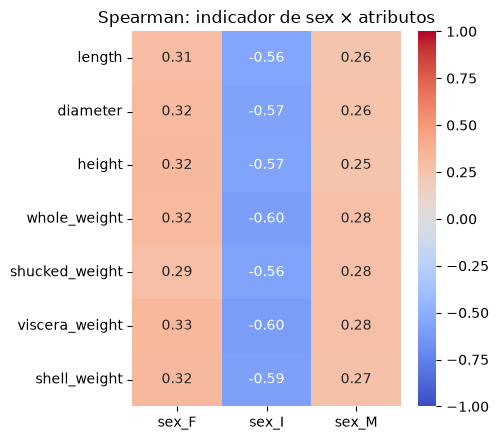

In [15]:
# Célula 22: Spearman um-contra-todos (sex com type e com os atributos numéricos)
dummies = pd.get_dummies(df["sex"], prefix="sex").astype(int)

# sex × type
linhas = {}
for c in dummies:
    rho, pv = spearmanr(dummies[c], df["type"])
    linhas[c] = {"spearman_com_type": rho, "p_valor": pv}
display(pd.DataFrame(linhas).T.round(4))

# sex × atributos numéricos
corr_sex_num = pd.DataFrame(
    {c: [spearmanr(dummies[c], df[a])[0] for a in num_cols] for c in dummies},
    index=num_cols,
)
display(corr_sex_num.round(3))

plt.figure(figsize=(5, 4.5))
sns.heatmap(corr_sex_num, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Spearman: indicador de sex × atributos")
plt.tight_layout()
plt.show()

In [16]:
# Célula 23: sex × atributos numéricos (informação mútua e Kruskal-Wallis)
mi_sex_num = mutual_info_classif(
    df[num_cols], df["sex"], discrete_features=False, random_state=RANDOM_STATE
)
kw = {a: kruskal(*[g[a].values for _, g in df.groupby("sex")]) for a in num_cols}

df_sex_num = pd.DataFrame({
    "info_mutua": mi_sex_num,
    "kruskal_H": [kw[a].statistic for a in num_cols],
    "p_valor": [kw[a].pvalue for a in num_cols],
}, index=num_cols)
display(df_sex_num.round(4))

,info_mutua,kruskal_H,p_valor
length,0.1836,995.9961,0.0
diameter,0.1961,1042.8732,0.0
height,0.1981,1021.2589,0.0
whole_weight,0.2009,1129.6195,0.0
shucked_weight,0.1987,999.8506,0.0
viscera_weight,0.2159,1150.1776,0.0
shell_weight,0.2112,1100.4170,0.0


,info_mutua_com_type
shell_weight,0.3130
height,0.2572
whole_weight,0.2511
diameter,0.2429
viscera_weight,0.2412
length,0.2335
shucked_weight,0.2071
sex,0.1402


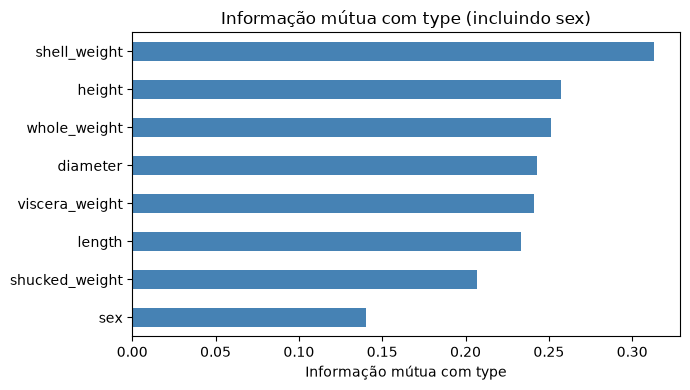

In [17]:
# Célula 24: onde o sex fica no ranking de informação mútua com type
# (mesma métrica da sua tabela da Etapa 1, agora incluindo sex)
Xr = df[num_cols].copy()
Xr["sex"] = df["sex"].astype("category").cat.codes
mascara_discreta = [False] * len(num_cols) + [True]

mi_type = mutual_info_classif(
    Xr, df["type"], discrete_features=mascara_discreta, random_state=RANDOM_STATE
)
ranking = pd.Series(mi_type, index=Xr.columns).sort_values(ascending=False)
display(ranking.round(4).to_frame("info_mutua_com_type"))

ranking.sort_values().plot(kind="barh", figsize=(7, 4), color="steelblue")
plt.xlabel("Informação mútua com type")
plt.title("Informação mútua com type (incluindo sex)")
plt.tight_layout()
plt.show()